In [ ]:
# Loading data
import pandas as pd
df = pd.read_csv('data/twitter_training.csv', header=None, names=['id','entity', 'sentiment', 'text'])
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         74682 non-null  int64
 1   entity     74682 non-null  str  
 2   sentiment  74682 non-null  str  
 3   text       73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


In [5]:
# Cleaning
df.isnull().sum()

id             0
entity         0
sentiment      0
text         686
dtype: int64

In [6]:
df = df.dropna(subset=['text'])
df = df.drop_duplicates()

In [10]:
# Checking sentiments distribution
df['sentiment'].value_counts()
df['sentiment'].value_counts(normalize=True)

sentiment
Negative      0.302808
Positive      0.275106
Neutral       0.247125
Irrelevant    0.174961
Name: proportion, dtype: float64

In [ ]:
# Tweets cleaning as it can be full of links, hastags, mentions etc.
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)                 # remove mentions
    text = re.sub(r'#\w+', '', text)                 # remove hashtags
    text = re.sub(r'[^a-z\s]', '', text)              # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra whitespace
    return text

df['clean_text'] = df['text'].apply(clean_text)

<Axes: xlabel='sentiment'>

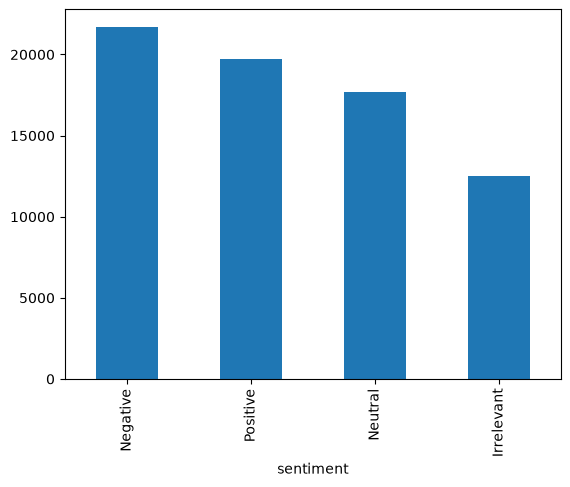

In [12]:
df['sentiment'].value_counts().plot(kind='bar')

In [13]:
df.groupby('entity')['sentiment'].value_counts().unstack()

sentiment,Irrelevant,Negative,Neutral,Positive
entity,,,,
Amazon,185,565,1197,302
ApexLegends,185,574,913,606
AssassinsCreed,256,365,153,1382
Battlefield,907,445,342,561
Borderlands,238,415,581,972
CS-GO,620,335,523,717
CallOfDuty,660,861,367,426
CallOfDutyBlackopsColdWar,545,540,340,817
Cyberpunk2077,457,360,456,902


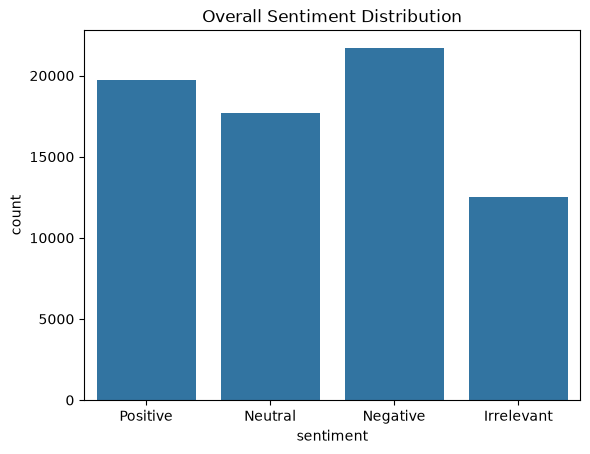

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
# Overall sentiment distribution
sns.countplot(x='sentiment', data=df)
plt.title("Overall Sentiment Distribution")
plt.show()


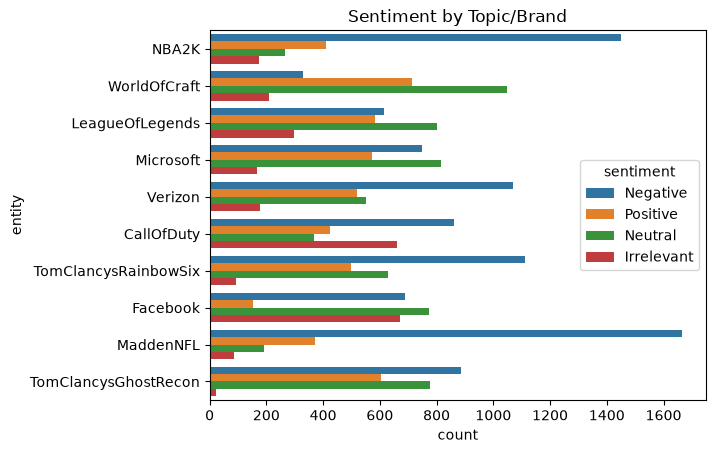

In [15]:
# Top entities by tweet volume, colored by sentiment
top_entities = df['entity'].value_counts().head(10).index
subset = df[df['entity'].isin(top_entities)]
sns.countplot(y='entity', hue='sentiment', data=subset)
plt.title("Sentiment by Topic/Brand")
plt.show()

In [18]:
from collections import Counter

positive_words = ' '.join(df[df['sentiment']=='Positive']['clean_text']).split()
Counter(positive_words).most_common(20)

[('the', 11621),
 ('i', 8879),
 ('to', 7519),
 ('and', 6804),
 ('a', 5837),
 ('of', 5006),
 ('is', 4360),
 ('for', 4300),
 ('this', 4130),
 ('it', 3931),
 ('in', 3728),
 ('my', 3216),
 ('on', 2759),
 ('so', 2671),
 ('you', 2499),
 ('that', 2429),
 ('game', 2224),
 ('with', 2173),
 ('be', 1780),
 ('but', 1732)]

In [17]:
stopwords = set(['the','i','to','and','a','of','is','for','this','it','in','my','on','so','you','that','with','be','but','are','was','have','at','not'])
positive_words_filtered = [w for w in positive_words if w not in stopwords]
Counter(positive_words_filtered).most_common(20)

[('game', 2224),
 ('im', 1727),
 ('me', 1722),
 ('love', 1703),
 ('just', 1658),
 ('all', 1601),
 ('good', 1551),
 ('its', 1449),
 ('like', 1324),
 ('really', 1266),
 ('new', 1180),
 ('out', 1101),
 ('now', 1091),
 ('best', 1086),
 ('as', 1056),
 ('one', 1036),
 ('from', 1008),
 ('play', 1008),
 ('time', 972),
 ('great', 954)]

## Key Findings

- Sentiment distribution was relatively balanced: Negative (~21,700), Positive (~19,700), Neutral (~17,700), Irrelevant (~12,500) — no severe class imbalance.
- Sentiment varied sharply by brand/topic:
  - **MaddenNFL** and **NBA2K** showed overwhelmingly negative sentiment, suggesting strong public dissatisfaction with these titles
  - **WorldOfCraft** was the only brand where Neutral sentiment exceeded Negative, standing out from the broadly negative pattern seen elsewhere
  - **Facebook** and **CallOfDuty** had unusually high "Irrelevant" tweet counts, likely due to the search terms picking up unrelated mentions
- After filtering stopwords, the most common words in positive tweets were "love," "good," "like," "best," and "great" — confirming the sentiment labels align well with actual language used, validating the dataset's quality
- "Game" and "play" appearing frequently across positive tweets reflects the gaming-heavy nature of the dataset's topics